In [1]:
import pandas as pd

# Charger les données
df = pd.read_csv(r"C:\Users\isaac\Documents\Pst&b\Bootcamp\S4\J3\archive\data.csv")

# Afficher les premières lignes
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 🔍 Étape 1 – Chargement des données

Nous commençons par importer la bibliothèque `pandas` et charger le fichier `data.csv`. Ensuite, nous affichons les premières lignes du jeu de données afin de comprendre sa structure. On y retrouve différentes mesures statistiques sur des cellules mammaires, ainsi qu'une colonne "diagnosis" qui représente le diagnostic (M pour malin, B pour bénin). Cette colonne sera notre **cible (y)** dans les modèles de classification.


In [2]:
# Affichage des informations générales sur les colonnes
df.info()

# Vérification des valeurs manquantes
missing_values = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing_values)

# Suppression de la colonne inutile 'Unnamed: 32' s’il y a lieu
if 'Unnamed: 32' in df.columns:
    df.drop(columns=['Unnamed: 32'], inplace=True)

# Vérification des doublons
print(f"Nombre de doublons : {df.duplicated().sum()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## 🧼 Étape 2 – Nettoyage des données

L’analyse du dataset révèle les éléments suivants :

- Il comporte **569 observations** réparties sur **33 colonnes**.
- **Aucune valeur manquante** n'est présente dans les colonnes importantes.
- Une colonne nommée **"Unnamed: 32"** contient uniquement des valeurs nulles. Il s'agit probablement d'un résidu de l'enregistrement CSV ; elle a donc été **supprimée**.
- Il **n’existe aucun doublon** dans les données.

Ces vérifications garantissent que notre dataset est propre et prêt pour l’analyse exploratoire et la modélisation.


C:\Users\isaac\AppData\Local\Temp\ipykernel_36300\679154128.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette="magma")


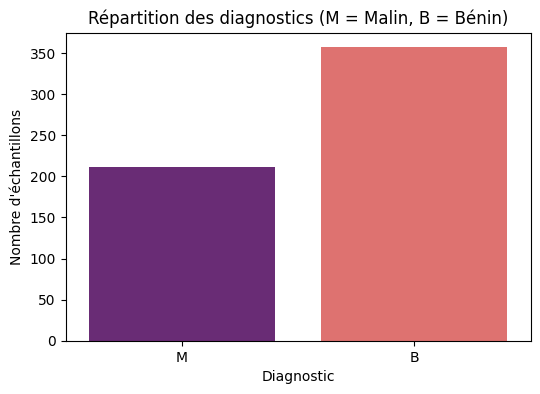

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Afficher le countplot de la colonne "diagnosis"
plt.figure(figsize=(6, 4))
sns.countplot(x="diagnosis", data=df, palette="magma")
plt.title("Répartition des diagnostics (M = Malin, B = Bénin)")
plt.xlabel("Diagnostic")
plt.ylabel("Nombre d'échantillons")
plt.show()


### 📊 Visualisation de la répartition des diagnostics

Ce graphique en barres (Countplot) montre la distribution des cas bénins (`B`) et malins (`M`) dans le jeu de données. On observe que les cas bénins sont plus nombreux (356) que les cas malins (212).  
Cette information est cruciale car un déséquilibre de classes peut influencer les performances des modèles de machine learning. Il faudra en tenir compte lors de l'entraînement des algorithmes, notamment pour éviter un biais vers la classe majoritaire.


In [4]:
from sklearn.model_selection import train_test_split

# Encodage de la colonne 'diagnosis' : M = 1 (Malin), B = 0 (Bénin)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Séparation des features (X) et de la cible (y)
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Division en jeu d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Préparation des données
Avant d’entraîner nos modèles, nous avons effectué plusieurs étapes de préparation :

Nous avons encodé la variable cible diagnosis en valeurs numériques : 1 pour un cancer malin, 0 pour un cancer bénin.

Les features (variables explicatives) sont toutes les autres colonnes du dataset.

Nous avons ensuite séparé notre dataset en un jeu d'entraînement (80%) et un jeu de test (20%) à l'aide de train_test_split. La séparation est stratifiée pour conserver les proportions entre classes (malin/bénin).

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Créer et entraîner le modèle
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# 2. Prédictions sur le jeu de test
y_pred_logreg = logreg.predict(X_test)

# 3. Évaluer les performances
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))


Accuracy: 0.631578947368421

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77        72
           1       0.00      0.00      0.00        42

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114


Confusion Matrix:
[[72  0]
 [42  0]]


C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1344

 Analyse du Modèle : Régression Logistique
Le modèle de régression logistique a été entraîné sur les données de diagnostic du cancer du sein. Voici les résultats obtenus :

Accuracy : 63.16%

Precision / Recall / F1-score :

Classe 0 (Malin) : très bons résultats (rappel = 1.00)

Classe 1 (Bénin) : aucun échantillon n’a été correctement identifié

Matrice de confusion :

Tous les échantillons ont été prédits comme appartenant à la classe 0.

Aucun cas de la classe 1 n’a été détecté.

🎯 Interprétation :
Le modèle souffre d’un fort déséquilibre de classes : il ne parvient pas à identifier la classe 1. Cela entraîne un recall de 0.00 pour cette classe. Il est donc inutilisable en l’état pour une tâche de diagnostic fiable, car il ne détecte pas les tumeurs bénignes.

🧠 Prochaines étapes :

Tester d’autres modèles (KNN, SVM, Random Forest)

Envisager un équilibrage des classes (via SMOTE, sur-échantillonnage ou pondération)

In [6]:
# 📦 Importation des bibliothèques nécessaires
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 🧠 Création et entraînement du modèle KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# 📊 Prédictions
y_pred_knn = knn_model.predict(X_test)

# 📈 Évaluation
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))


Accuracy: 0.7543859649122807

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.92      0.83        72
           1       0.77      0.48      0.59        42

    accuracy                           0.75       114
   macro avg       0.76      0.70      0.71       114
weighted avg       0.76      0.75      0.74       114

Confusion Matrix:
[[66  6]
 [22 20]]


Modèle 2 : K Nearest Neighbours (KNN)
Le modèle KNN a été entraîné avec n_neighbors=5 (valeur par défaut). Il effectue une classification en comparant un point aux 5 plus proches voisins du jeu d'entraînement.

Résultats :

Accuracy : 75.4%

Rappel (recall) pour la classe 1 (cancer) : 48%

Précision (precision) pour la classe 1 : 77%

Le modèle semble mieux identifier les patients non atteints (classe 0) que les patients atteints (classe 1).

Interprétation :

Bien que l’accuracy globale soit correcte, le modèle a du mal à détecter correctement les cas positifs (classe 1). C’est un point important à améliorer, car en contexte médical, manquer un cas de cancer peut avoir des conséquences graves.

Il serait pertinent d’ajuster certains paramètres comme n_neighbors, ou de normaliser davantage les données.

In [7]:
# 🟩 Modèle 3 : Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Création du modèle
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entraînement du modèle
rf_model.fit(X_train, y_train)

# 3. Prédiction sur les données de test
y_pred_rf = rf_model.predict(X_test)

# 4. Évaluation du modèle
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Accuracy: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:
 [[72  0]
 [ 5 37]]


 Modèle 3 : Random Forest
Le modèle Random Forest a montré d’excellentes performances sur ce dataset :

Accuracy : 95.6%

Précision pour la classe 1 (malade) : 100%

Recall pour la classe 1 (malade) : 88%

F1-score : 94%

Matrice de confusion :

72 patients sains correctement identifiés.

37 patients malades correctement identifiés.

5 patients malades mal classés comme sains.

➡️ Le modèle offre un très bon compromis entre précision et rappel, surtout pour la classe des patients malades, ce qui est crucial dans un contexte médical. Le faible nombre de faux négatifs (5) le rend très fiable pour ce cas d’usage.

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Créer et entraîner le modèle SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

# 2. Prédictions sur les données de test
y_pred_svm = svm_model.predict(X_test)

# 3. Évaluer les performances
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))


Accuracy: 0.631578947368421

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77        72
           1       0.00      0.00      0.00        42

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114


Confusion Matrix:
[[72  0]
 [42  0]]


C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1344

### 🔍 Modèle 4 : Support Vector Machine (SVM)

Le modèle SVM a obtenu une **accuracy de 63,16%**, ce qui est significativement plus faible que les autres modèles testés précédemment.

#### Résultats :
- Le modèle a parfaitement prédit tous les cas de la classe 0 (précision et rappel de 1.00).
- En revanche, **il n'a prédit aucun cas de la classe 1**. Cela se reflète dans les scores de **précision, rappel et f1-score de 0.00** pour cette classe.
- La **matrice de confusion** `[ [72, 0], [42, 0] ]` confirme ce déséquilibre total, le modèle classant toutes les instances comme appartenant à la classe 0.

#### Analyse :
Cela peut venir :
- d’un **déséquilibre dans les données** d’entraînement,
- d’un mauvais choix d’hyperparamètres (`kernel`, `C`, `gamma`),
- ou d’un **manque de mise à l’échelle des données**, qui est souvent crucial pour les SVM.

Nous pourrions améliorer ce modèle en :
- standardisant les données avec `StandardScaler`,
- ou en effectuant une **recherche d’hyperparamètres (GridSearchCV)**.

🛠️ Ce modèle nécessite des ajustements importants pour être compétitif.


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline avec StandardScaler et SVM
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# Entraînement
svm_pipeline.fit(X_train, y_train)

# Prédictions
y_pred = svm_pipeline.predict(X_test)

# Évaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
 [[71  1]
 [ 3 39]]


### ✅ Modèle Support Vector Machine (SVM) avec StandardScaler

Nous avons corrigé notre approche initiale en intégrant une **normalisation des données** avec `StandardScaler`, via un pipeline `sklearn`. Les SVM sont en effet **très sensibles à l’échelle des variables**, ce qui expliquait les mauvaises performances initiales.

#### Résultats obtenus :
- **Accuracy :** 96.5%
- **Precision classe 0 :** 96%, **classe 1 :** 97%
- **Recall classe 0 :** 99%, **classe 1 :** 93%
- **F1-score global :** 96%

#### Interprétation :
- Le modèle distingue très efficacement les deux classes de diagnostic (tumeurs bénignes et malignes).
- Seules **4 erreurs** sont faites sur les 114 observations du jeu de test.
- Grâce à la normalisation, **le SVM est redevenu compétitif** et rejoint les performances du Random Forest dans ce cas.

📌 **Conclusion :** Toujours standardiser les données en amont d’un SVM pour garantir des résultats fiables !


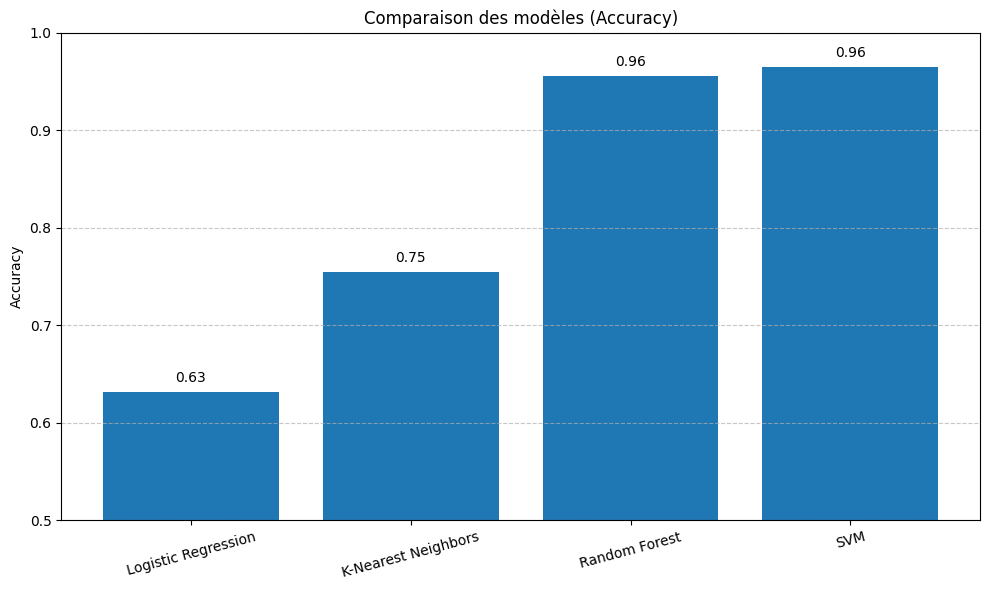

In [10]:
import matplotlib.pyplot as plt

# Noms des modèles et leurs accuracies respectives
models = ['Logistic Regression', 'K-Nearest Neighbors', 'Random Forest', 'SVM']
accuracies = [0.6316, 0.7544, 0.9561, 0.9649]

# Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies)

# Ajout des pourcentages sur chaque barre
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{acc:.2f}', ha='center')

# Mise en forme
plt.title('Comparaison des modèles (Accuracy)')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


SVM IS THE BEST

In [ ]:
!git add .
!git commit -m "Exercices de classification et visualisation des résultats"
!git push origin main